# Stability of Rankings LIME vs SHAP
This notebook will try and investigate the differences in the stability of the rankings produced by the two methods  

**Verdict**  
Across the diferent datasets and models, LIME tend to produce rankings that fluctuate more than SHAP, i.e. the rankings produced by LIME are more unstable. This is more evident in some datasets than others. Even when rankings are based on models trained on identical datasets, LIME tends to produce other rankings for each iteration, which goes against all asumptions, since we would like to get the same results if we gave it the same input dataset. There is also a difference in the stability of the models and across datasets. While it is not much, forest yields slighly more stable rankings

In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["adult","usa_house","usa_house_old", "cervic_cancer", "adult_imbalanced", "old_adult"],
    "../data/",
)

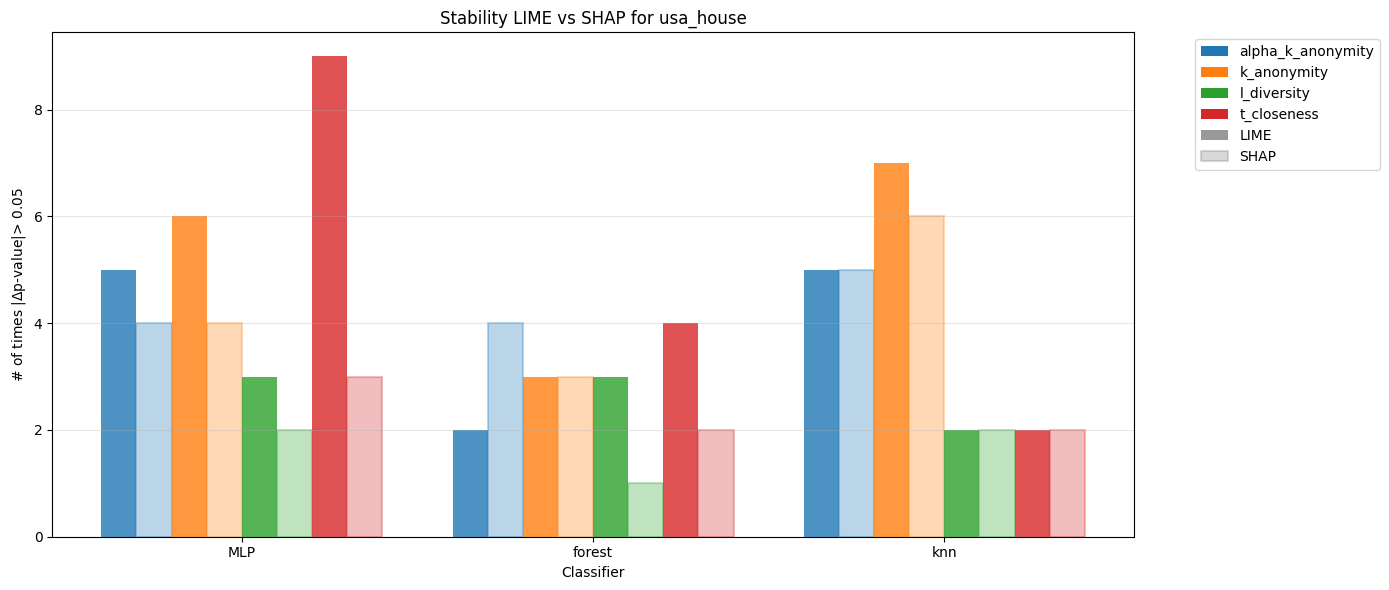

In [10]:
pl.plot_histogram("usa_house", threshold=0.05)

This shows that LIME produces rankings that tend to to change more times. Note, here we are looking at the amount of times the pvalue changes with more than 0.05. 5% has been chosen becaue it is often used in the litterature for significance measuring. If there is a p-value of 0, such a change would make the correlation not significant.  
Consider the next plot

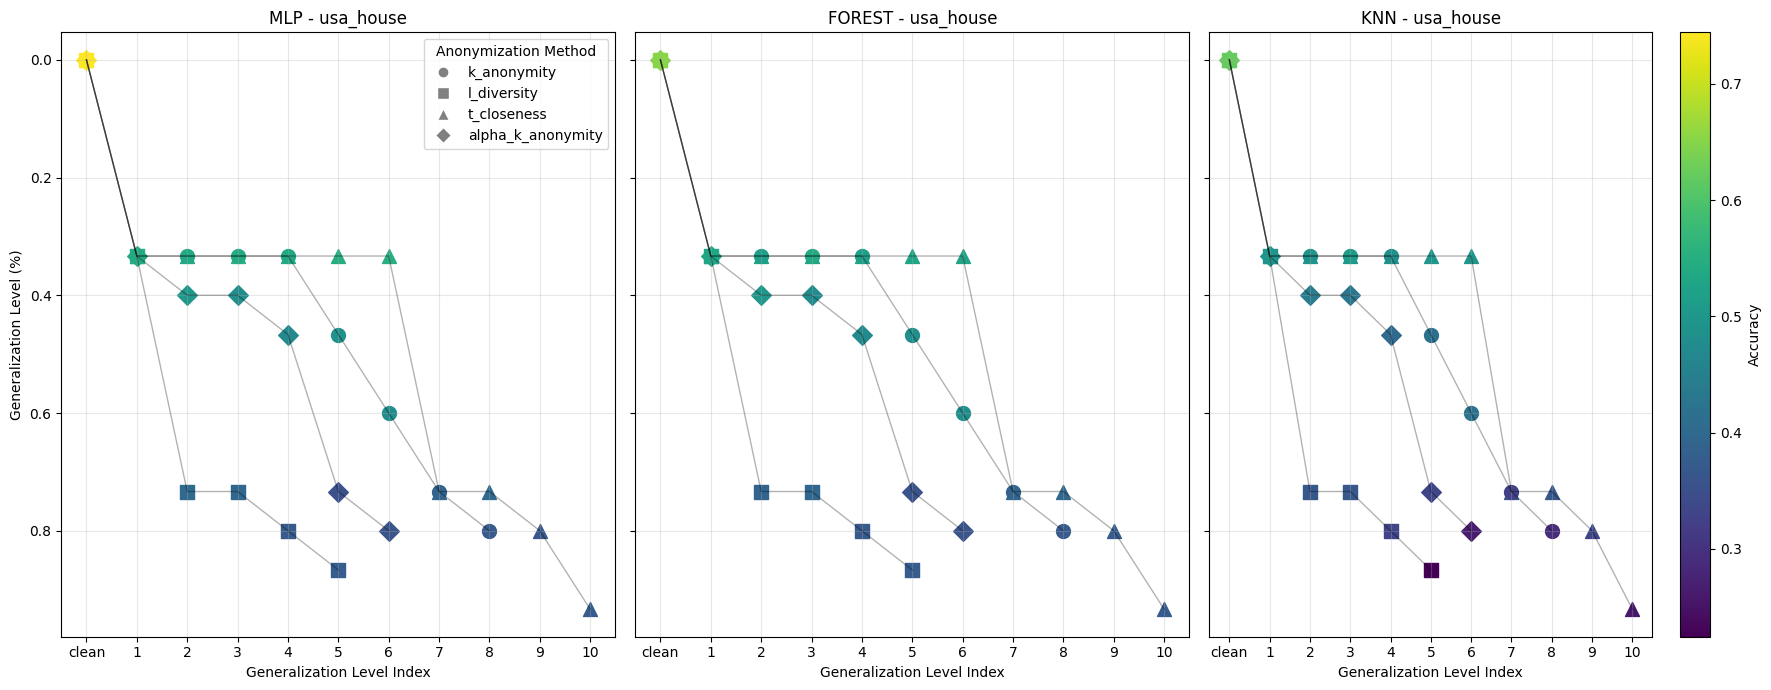

In [4]:
pl.plot_utility("usa_house", ["MLP", "forest", "knn"])

We see here that generally the accuracy falls as the data is more generalized. We also see that k_anonymity and especially t_closeness produces a dataset early that satisfy the increasing values of k and t. Also note, that it is in these that the instability of LIME specially dominates SHAP. This is however only true for MLP. Generally, the performance is affected equally

Let us consider how MLP compares with the other plots, because it looks quite a bit more unstable compared to the other ones

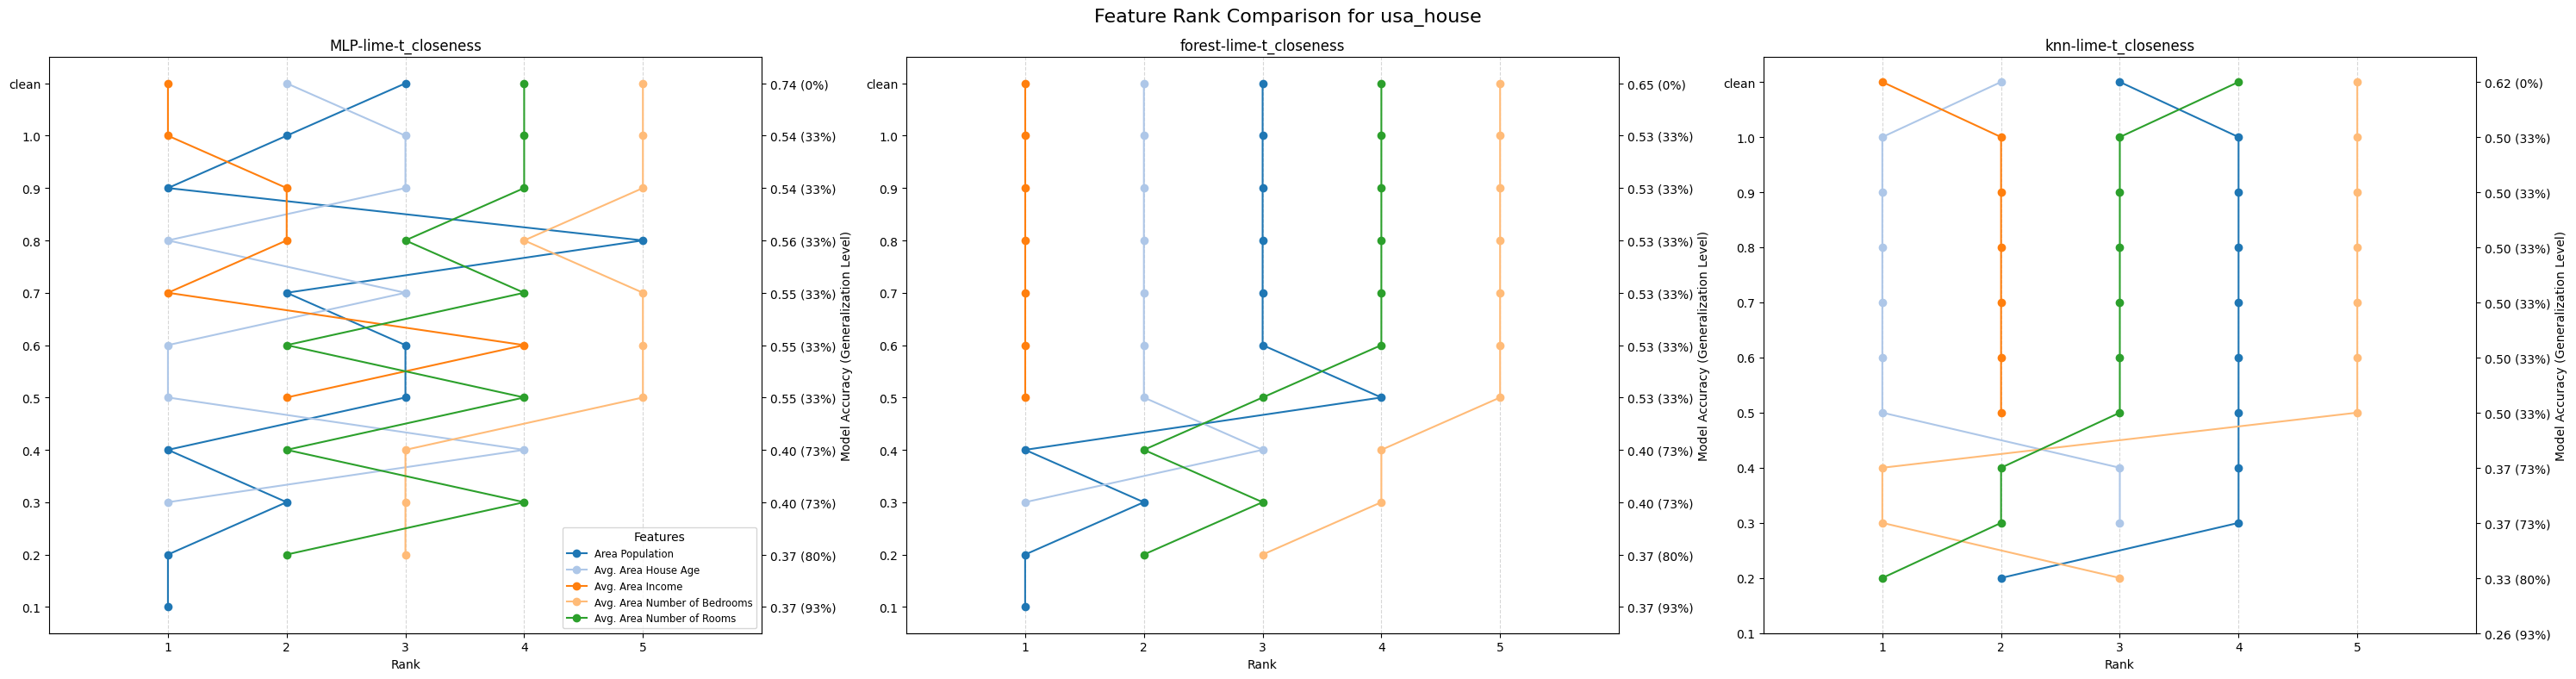

In [4]:
pl.plot_line_compare("usa_house", ["MLP-lime-t_closeness", "forest-lime-t_closeness", "knn-lime-t_closeness"])

As expected, the MLP model is much more unstable. The usa house has between 4000 and 5000 points in it after anonymization, and for each LIME explanation at least 150000 points are used, i.e. all the points are used every time. The fact that the rankings look different probably comes down to the fact that the 1000 representative explanations used are different for every dataset

Let us consider another dataset. Note, this dataset is the only dataset that was allow to suppress 30% of it's instances

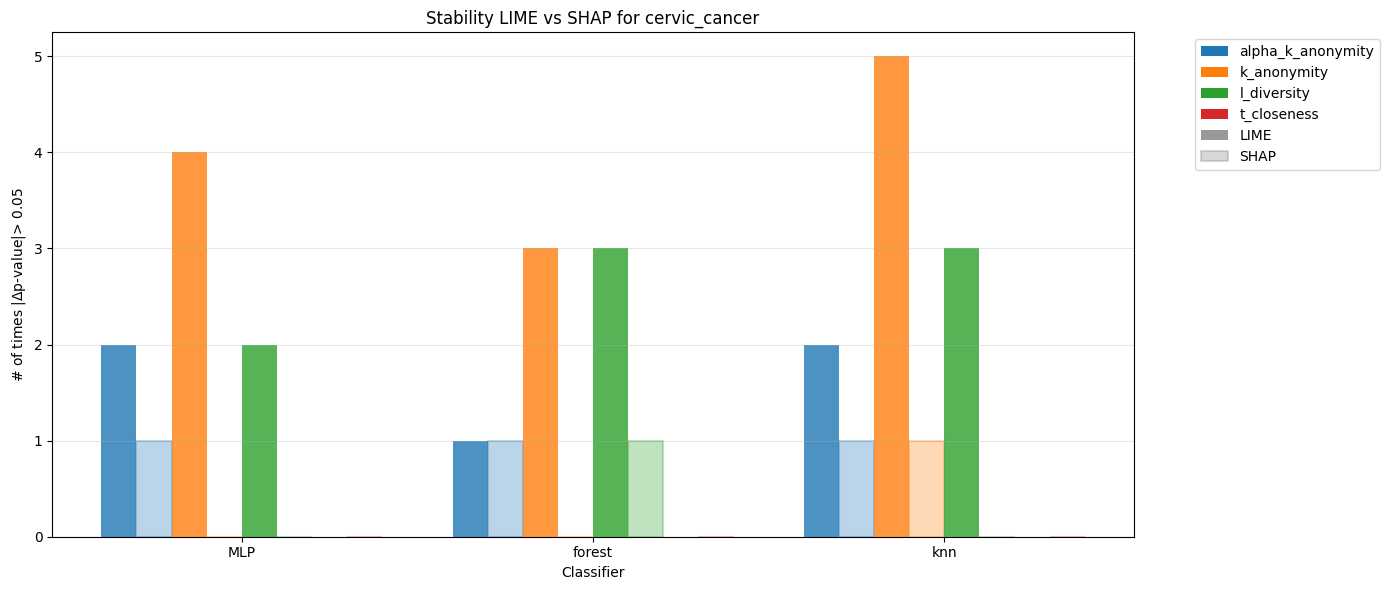

In [11]:
pl.plot_histogram("cervic_cancer", threshold=0.05)

Here it is even more evident. SHAP outperforms LIME in every model. The reason some categories are missing is because the difference is simply not that large at any time. How come?

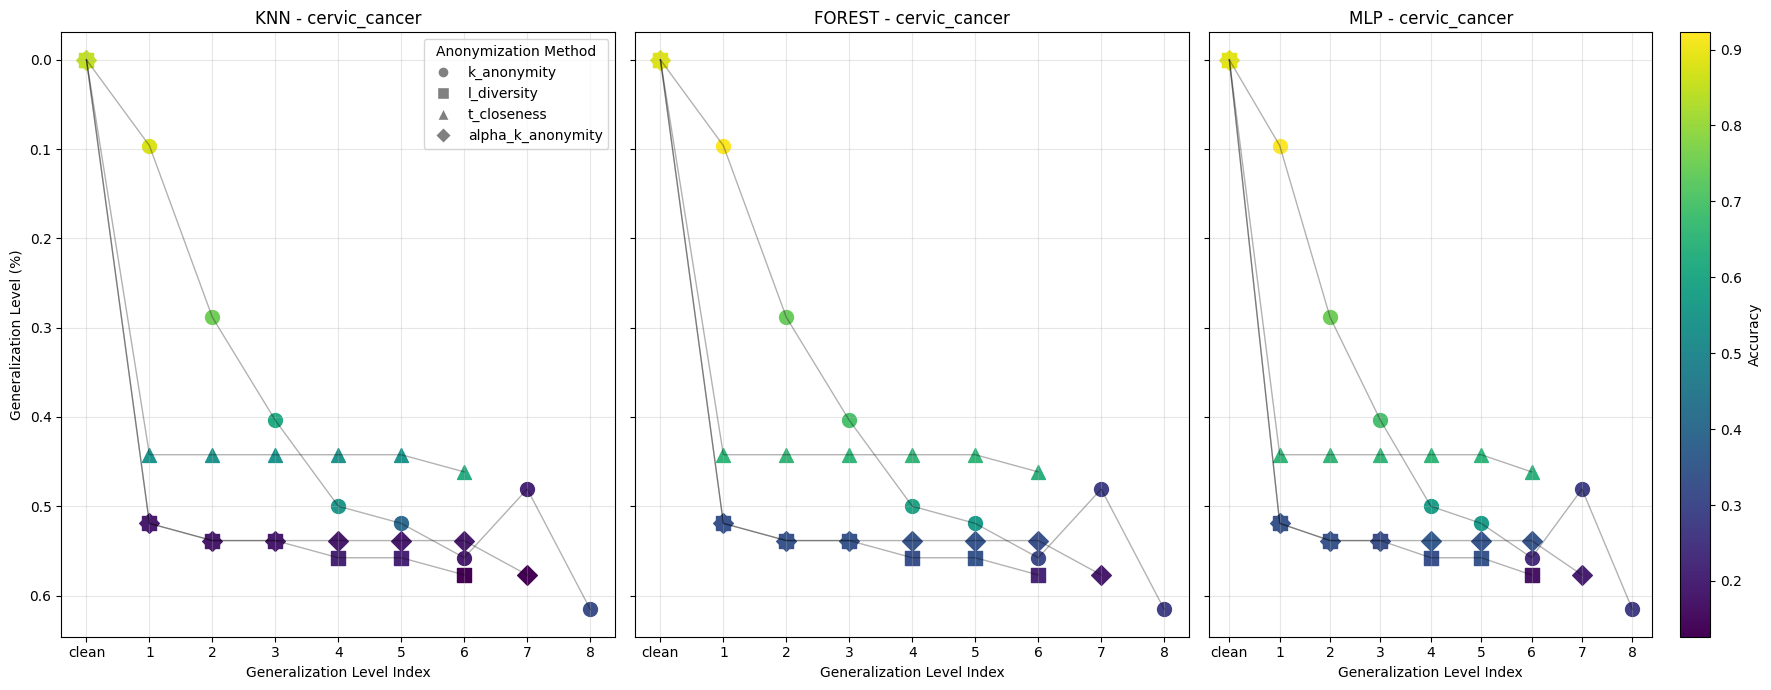

In [5]:
pl.plot_utility("cervic_cancer")

**Note** the weird behavoir at level 7 for k-anonymity. This behavoir stems from the fact that the generalization level is not calculated the right way. There is something wrong with the implementation. Chances are that one of the numbers are treated as a floating point which means that my patch work implementation for floating points messes with things. It is only the generalization level that is a bit messed up, some outlier. The accuracy is still correct.

We see here that the dataset is generalized quickly, further indicating that some anonymization models are more expensive to force onto some datasets. This dataset consists of many binary fearues whcih are anonymized in the order in which they appear in the dataframe.  
**Note** Changing the order of the features to the reverese result in a scenario where most of the datasets cannot be generated, showing that the hiearchy plays a major role

Now let us consider the adult dataset

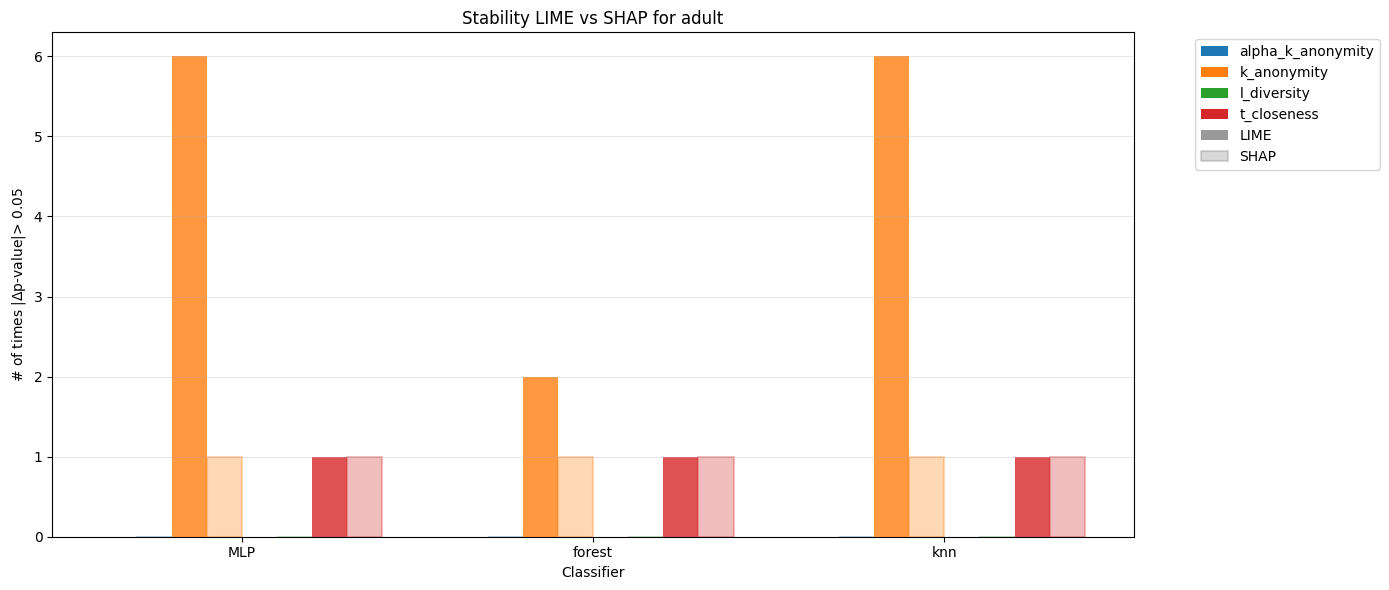

In [3]:
pl.plot_histogram("adult", threshold=0.05)

Now what is up with the lack of boxes? Easy, the Adult dataset is a binary dataset, so l_diversity can only be done once there is nothing to compare to. Also, we again see that LIME is much more unstable than SHAP. Here we see that MLP and knn are equally unstable while forests stays quite good

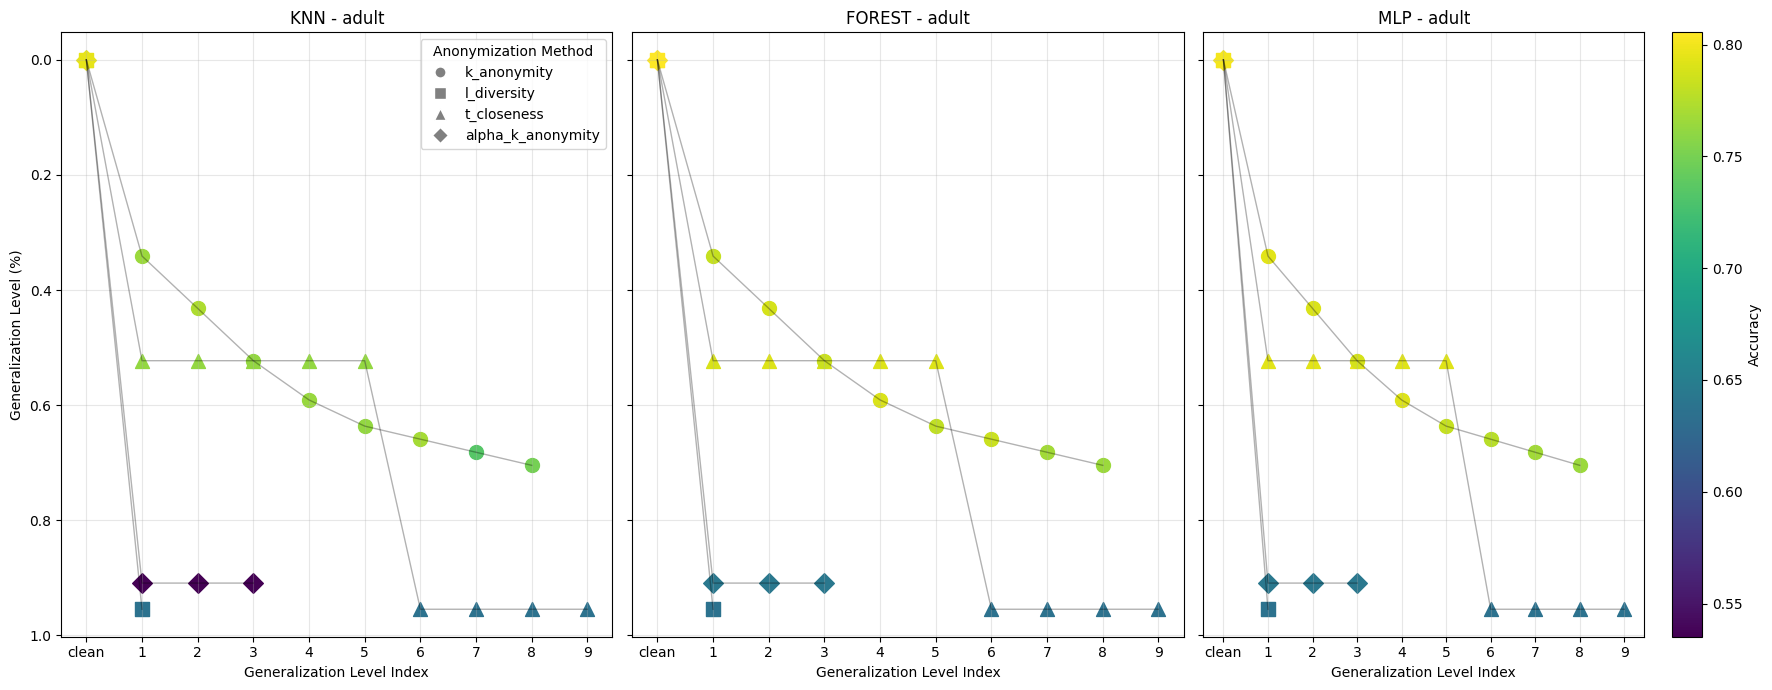

In [4]:
pl.plot_utility("adult")

Note here that the accuracies are quite high. Initially it is quite good estimating income but as the dataset is genealized more the accuracy falls considerable. Also note that it never drops below 50. It is very dangerous to draw conclussions about the models utility from these plots, since we do not know the distribution of the target variable. Worst case scenario, the 20% that could be suppressed could al be focused on on target class, changing the distribution from 50 vs 50 to 70 vs 30. If that indeed happens, the model performs very poorly.  
We also see that in spite of the histogram not showing any values for alpha_k_anonymity, there is multiple datsets that satisfy alpha_k_anonymity. We must investigate further  
Also note, that k anonymity can be fulfilled by generalizing the dataset a little more, indicating that it is easy making equivalence classes. This indicates that the hierarchy chosen is well served for anonymizing such that it fulfills k_anonymity.  

In [9]:
pd.read_csv("../data/adult/k_anonymity/128.csv")['income'].value_counts(normalize=True)

income
<=50K    0.533609
>50K     0.466391
Name: proportion, dtype: float64

It seems that the suppression processes did a rather good job of suppressing rows rather equally from both target classes. This also means, however, as the models becomes more generalized, it only becomes a little bit better than random guessing, which is not good at all. Were these models to be used in practice, the final model had undergo some scrutiny to characterize why it behaves as it does. 

Now let us investigate why alpha_k_anonymity is so anonymous in the histogram plot

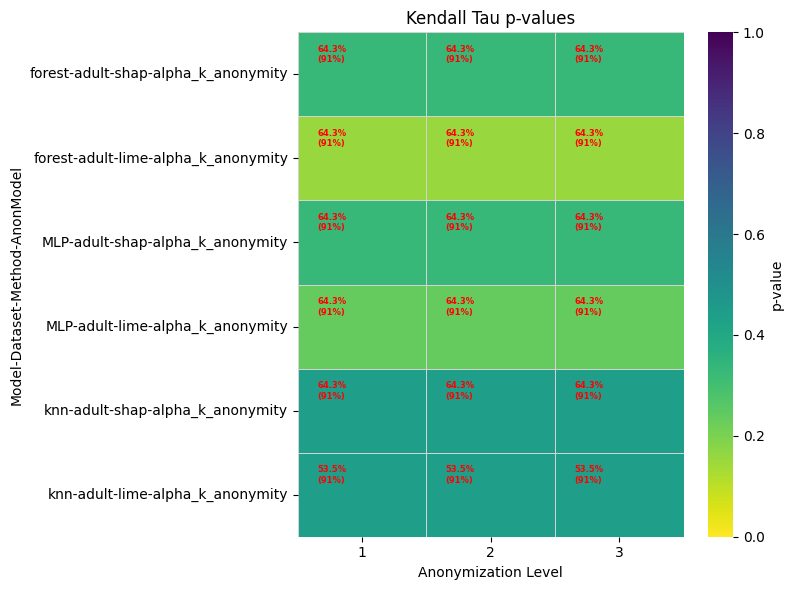

In [6]:
pl.plot_heatmap("adult", ["alpha_k_anonymity"])

It looks like all the rankings produced are in 100% agreement. That is rather rare, especially since the dataset is generalized to an equal extent. It is in contrast to our other findings. Let us investigate further

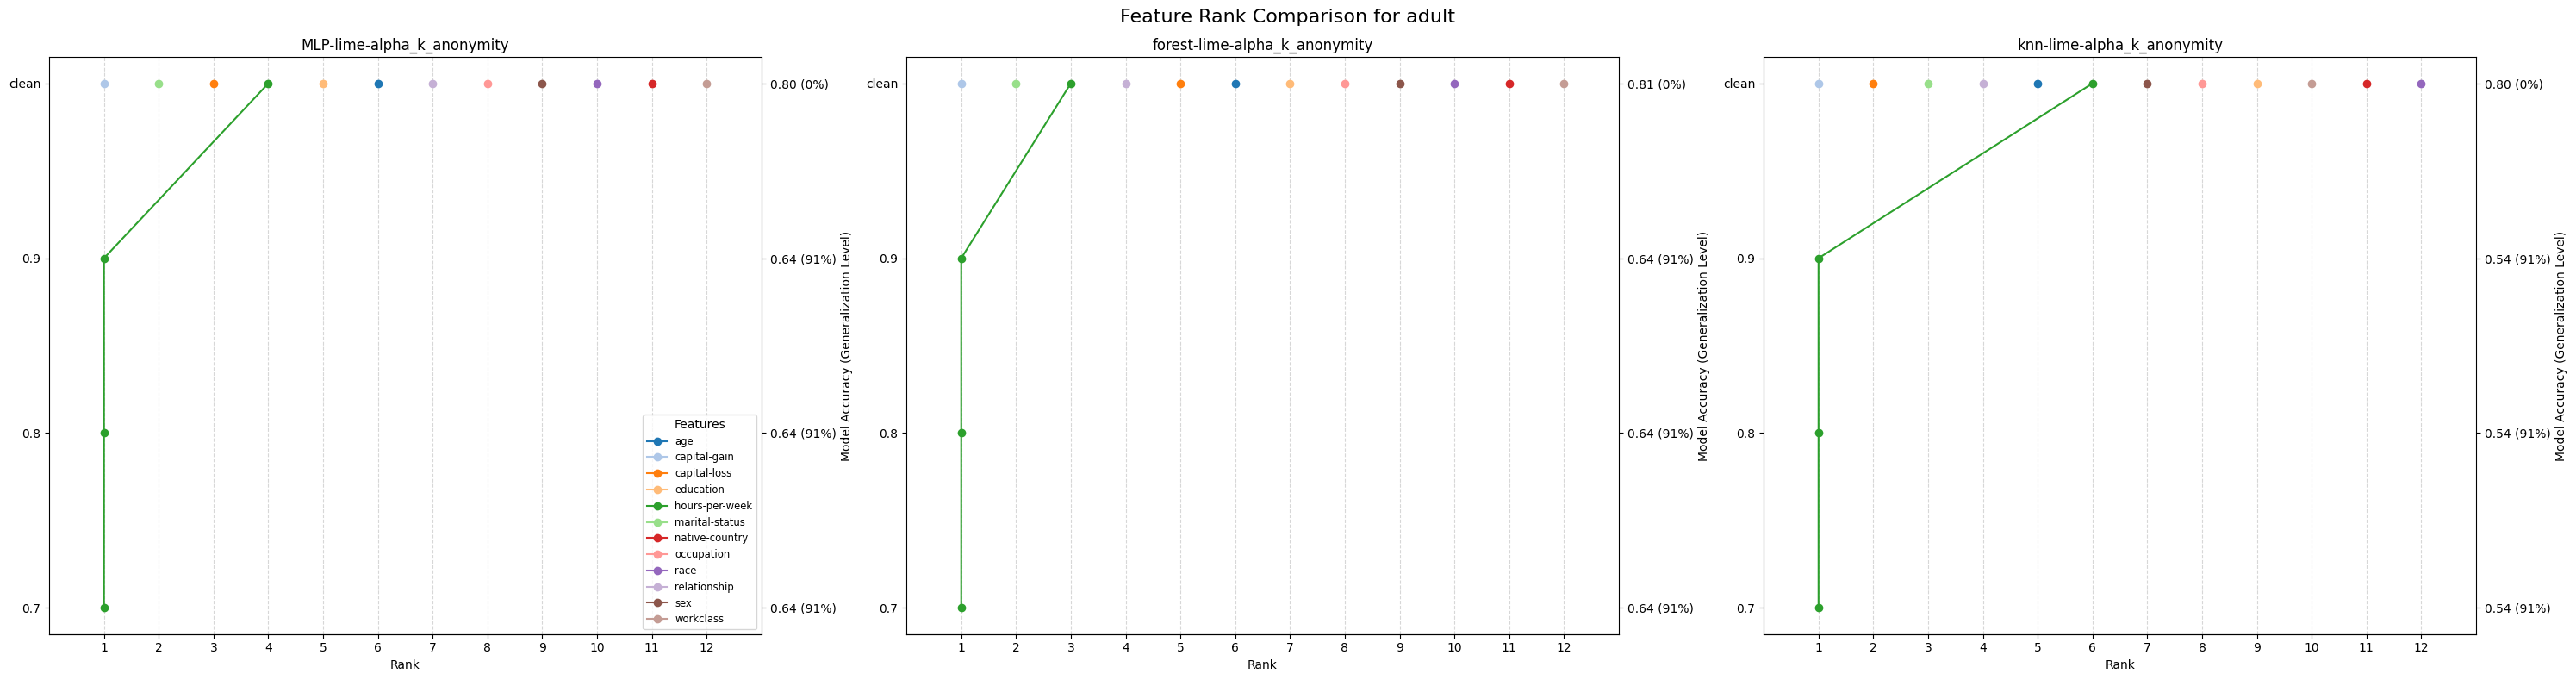

In [10]:
pl.plot_line_compare("adult", ["MLP-lime-alpha_k_anonymity", "forest-lime-alpha_k_anonymity", "knn-lime-alpha_k_anonymity"])

And here we have the reason. The dataset is anonymized to such a degree that only hours-per-week remain, making it impossible for the rankings to disagree with one another